# Module 1 — Feature Engineering & EDA
## Misinformation Verification Pipeline
### Input: LIAR dataset raw TSV files
### Output: features.json — enriched, structured records for downstream modules

In [1]:
!pip install transformers spacy pandas tqdm -q
!python -m spacy download en_core_web_sm -q

import json, re, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import spacy
from transformers import pipeline

nlp = spacy.load("en_core_web_sm")
print("Ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 84.9 MB/s eta 0:00:0000:010:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Ready.


## 6. Label Engineering
We create both the original 6-way label and a binary version:
- **True** (1): true, mostly-true
- **False** (0): false, barely-true, pants-fire
- **Uncertain** (None): half-true — excluded from binary tasks

This binary label is what RoBERTa fine-tuning and Bayesian inference target.

In [2]:
LABEL_TO_BINARY = {
    "true":        1,
    "mostly-true": 1,
    "half-true":   None,
    "barely-true": 0,
    "false":       0,
    "pants-fire":  0
}

LABEL_TO_INT = {
    "pants-fire":  0,
    "false":       1,
    "barely-true": 2,
    "half-true":   3,
    "mostly-true": 4,
    "true":        5
}

print("Label mappings defined.")

Label mappings defined.


## 3. Speaker Credibility Score
LIAR includes each speaker's historical verdict counts.
We use these to compute a lie rate — the proportion of their
past claims that were false, barely-true, or pants-fire.
This becomes a strong prior for Bayesian inference downstream.

In [3]:
def compute_speaker_lie_rate(row):
    try:
        barely_n = int(row["barely_true_counts"]) if row["barely_true_counts"].strip() else 0
        false_n  = int(row["false_counts"])        if row["false_counts"].strip()        else 0
        half_n   = int(row["half_true_counts"])    if row["half_true_counts"].strip()    else 0
        mostly_n = int(row["mostly_true_counts"])  if row["mostly_true_counts"].strip()  else 0
        pants_n  = int(row["pants_fire_counts"])   if row["pants_fire_counts"].strip()   else 0

        total = barely_n + false_n + half_n + mostly_n + pants_n
        if total == 0:
            return 0.5

        lies = false_n + barely_n + pants_n
        return round(lies / total, 4)
    except:
        return 0.5

print("compute_speaker_lie_rate defined.")

compute_speaker_lie_rate defined.


## 5. Text Feature Engineering
Simple linguistic features from the claim text:
- Does it contain numbers? (numeric claims are more verifiable)
- Does it contain percentages?
- Does it contain dollar amounts?
- Claim word count
- Does the claim start with "Says" (common in LIAR — indirect reported speech)

In [4]:
def extract_text_features(text):
    """Extract lightweight linguistic features from claim text."""
    if not text:
        return {}
    return {
        "claim_length":     len(text),
        "word_count":       len(text.split()),
        "has_number":       bool(re.search(r'\b\d+\b', text)),
        "has_percentage":   bool(re.search(r'\d+\s*%', text)),
        "has_dollar":       bool(re.search(r'\$[\d,]+', text)),
        "has_year":         bool(re.search(r'\b(19|20)\d{2}\b', text)),
        "is_reported_speech": text.strip().lower().startswith("says"),
        "question_claim":   "?" in text,
    }

# Test
sample = "Says the unemployment rate dropped to 3.7% in 2019."
print("Text features:", extract_text_features(sample))

Text features: {'claim_length': 51, 'word_count': 9, 'has_number': True, 'has_percentage': True, 'has_dollar': False, 'has_year': True, 'is_reported_speech': True, 'question_claim': False}


## 4. Named Entity Recognition
We use spaCy to extract named entities from each claim.
These are used in Module 3 for knowledge graph construction.
Unlike the old approach, we do NOT try to extract triples from text —
we use the structured LIAR metadata for subjects and topics instead.
NER here is supplementary — it enriches the record, not the backbone.

In [5]:
def extract_ner(text):
    """Extract named entities using spaCy. Returns list of (text, label) tuples."""
    if not text or not text.strip():
        return []
    doc = nlp(text[:512])  # cap length
    return [
        {"word": ent.text.strip(), "type": ent.label_}
        for ent in doc.ents
        if ent.label_ in {"PERSON", "ORG", "GPE", "LOC", "NORP", "FAC"}
        and len(ent.text.strip()) > 1
    ]

# Test
sample = "Barack Obama signed the Affordable Care Act in Washington."
print("NER test:", extract_ner(sample))

NER test: [{'word': 'Barack Obama', 'type': 'PERSON'}, {'word': 'Washington', 'type': 'GPE'}]


## 1. Load LIAR Dataset
LIAR has 3 splits: train, validation, test.
Each row has 14 columns including the claim text, speaker metadata,
speaker lie history counts, and the ground truth label.

In [6]:
LIAR_COLUMNS = [
    "id", "label", "statement", "subject", "speaker",
    "job_title", "state", "party",
    "barely_true_counts", "false_counts", "half_true_counts",
    "mostly_true_counts", "pants_fire_counts", "context"
]

DATA_DIR = "/kaggle/input/datasets/doanquanvietnamca/liar-dataset"

def load_split(filename, split_name):
    df = pd.read_csv(
        f"{DATA_DIR}/{filename}",
        sep="\t", header=None,
        names=LIAR_COLUMNS, dtype=str
    )
    df.fillna("", inplace=True)
    df["split"] = split_name  # ← tag BEFORE concat
    return df

df_train = load_split("train.tsv", "train")
df_val   = load_split("valid.tsv", "val")
df_test  = load_split("test.tsv",  "test")

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
df_all["speaker_lie_rate"] = df_all.apply(compute_speaker_lie_rate, axis=1)
df_all["label_binary"]     = df_all["label"].map(LABEL_TO_BINARY)
df_all["label_int"]        = df_all["label"].map(LABEL_TO_INT)

print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")
print(f"Total: {len(df_all):,}")
print(f"Columns: {list(df_all.columns)}")

Train: 10,240 | Val: 1,284 | Test: 1,267
Total: 12,791
Columns: ['id', 'label', 'statement', 'subject', 'speaker', 'job_title', 'state', 'party', 'barely_true_counts', 'false_counts', 'half_true_counts', 'mostly_true_counts', 'pants_fire_counts', 'context', 'split', 'speaker_lie_rate', 'label_binary', 'label_int']


## 2. Exploratory Data Analysis
Before building features, we understand the dataset:
- Label distribution
- Speaker diversity
- Claim length patterns
- Topic distribution

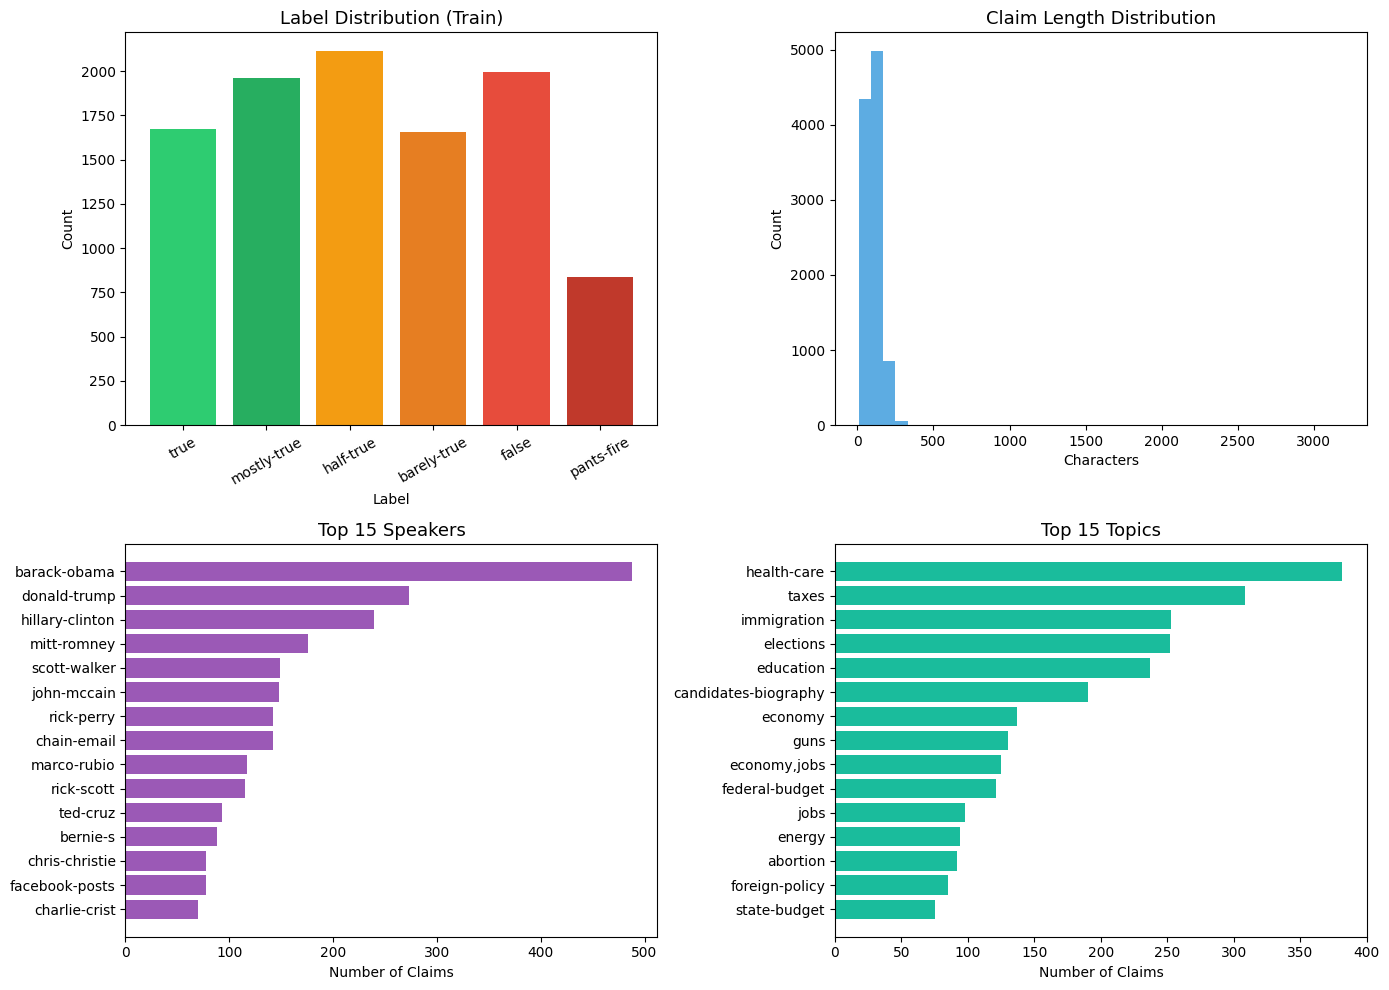

Saved eda_overview.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1 — Label distribution
label_order = ["true","mostly-true","half-true","barely-true","false","pants-fire"]
label_counts = df_train["label"].value_counts().reindex(label_order)
axes[0,0].bar(label_order, label_counts.values, 
              color=["#2ecc71","#27ae60","#f39c12","#e67e22","#e74c3c","#c0392b"])
axes[0,0].set_title("Label Distribution (Train)", fontsize=13)
axes[0,0].set_xlabel("Label")
axes[0,0].set_ylabel("Count")
axes[0,0].tick_params(axis='x', rotation=30)

# Plot 2 — Claim length distribution
df_train["claim_length"] = df_train["statement"].str.len()
axes[0,1].hist(df_train["claim_length"], bins=40, color="#3498db", alpha=0.8)
axes[0,1].set_title("Claim Length Distribution", fontsize=13)
axes[0,1].set_xlabel("Characters")
axes[0,1].set_ylabel("Count")

# Plot 3 — Top 15 speakers
top_speakers = df_train["speaker"].value_counts().head(15)
axes[1,0].barh(top_speakers.index[::-1], top_speakers.values[::-1], color="#9b59b6")
axes[1,0].set_title("Top 15 Speakers", fontsize=13)
axes[1,0].set_xlabel("Number of Claims")

# Plot 4 — Top 15 topics
top_topics = df_train["subject"].value_counts().head(15)
axes[1,1].barh(top_topics.index[::-1], top_topics.values[::-1], color="#1abc9c")
axes[1,1].set_title("Top 15 Topics", fontsize=13)
axes[1,1].set_xlabel("Number of Claims")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved eda_overview.png")

## 7. Build Feature Records
Combine all features into one JSON record per claim.
This is the output contract that all downstream modules depend on.

In [8]:
print("Building feature records...")
feature_records = []

for _, row in tqdm(df_all.iterrows(), total=len(df_all)):
    text    = str(row["statement"]).strip()
    speaker = str(row["speaker"]).strip()
    topic   = str(row["subject"]).strip()

    text_feats = extract_text_features(text)
    ner_ents   = extract_ner(text)

    record = {
        # Identity
        "claim_id":           str(row["id"]),
        "raw_claim":          text,
        "label":              str(row["label"]),
        "label_binary":       row["label_binary"],
        "label_int":          row["label_int"],
        "split":              str(row["split"]),

        # Speaker metadata
        "speaker":            speaker,
        "party":              str(row["party"]).strip(),
        "job_title":          str(row["job_title"]).strip(),
        "state":              str(row["state"]).strip(),
        "context":            str(row["context"]).strip(),

        # Topic
        "topic":              topic,

        # Speaker credibility
        "speaker_lie_rate":   float(row["speaker_lie_rate"]),
        "false_counts":       str(row["false_counts"]),
        "barely_true_counts": str(row["barely_true_counts"]),
        "pants_fire_counts":  str(row["pants_fire_counts"]),
        "half_true_counts":   str(row["half_true_counts"]),
        "mostly_true_counts": str(row["mostly_true_counts"]),

        # Text features
        **text_feats,

        # NER
        "ner_entities":       ner_ents,
    }
    feature_records.append(record)

print(f"Built {len(feature_records)} records")

Building feature records...


100%|██████████| 12791/12791 [01:21<00:00, 157.41it/s]

Built 12791 records


In [9]:
with open("features.json", "w", encoding="utf-8") as f:
    json.dump(feature_records, f, indent=2, ensure_ascii=False, default=str)

print(f"Saved {len(feature_records)} records to features.json")
print("\nSample record:")
print(json.dumps(feature_records[2], indent=2))

Saved 12791 records to features.json

Sample record:
{
  "claim_id": "324.json",
  "raw_claim": "Hillary Clinton agrees with John McCain \"by voting to give George Bush the benefit of the doubt on Iran.\"",
  "label": "mostly-true",
  "label_binary": 1.0,
  "label_int": 4,
  "split": "train",
  "speaker": "barack-obama",
  "party": "democrat",
  "job_title": "President",
  "state": "Illinois",
  "context": "Denver",
  "topic": "foreign-policy",
  "speaker_lie_rate": 0.3171,
  "false_counts": "71",
  "barely_true_counts": "70",
  "pants_fire_counts": "9",
  "half_true_counts": "160",
  "mostly_true_counts": "163",
  "claim_length": 105,
  "word_count": 19,
  "has_number": false,
  "has_percentage": false,
  "has_dollar": false,
  "has_year": false,
  "is_reported_speech": false,
  "question_claim": false,
  "ner_entities": [
    {
      "word": "Hillary Clinton",
      "type": "PERSON"
    },
    {
      "word": "John McCain",
      "type": "PERSON"
    },
    {
      "word": "George Bu

## 8. Feature Analysis
Validate that our engineered features are meaningful —
i.e. they differ across true vs false claims.

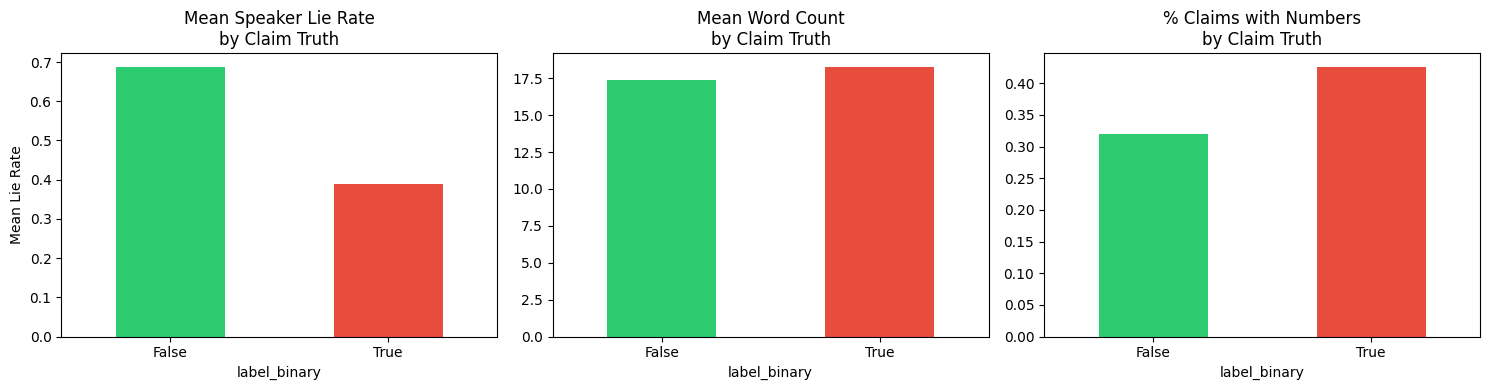

In [10]:
df_feat = pd.DataFrame(feature_records)
df_binary = df_feat[df_feat["label_binary"].notna()].copy()
df_binary["label_binary"] = df_binary["label_binary"].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Lie rate vs label
df_binary.groupby("label_binary")["speaker_lie_rate"].mean().plot(
    kind="bar", ax=axes[0], color=["#2ecc71","#e74c3c"])
axes[0].set_title("Mean Speaker Lie Rate\nby Claim Truth")
axes[0].set_xticklabels(["False","True"], rotation=0)
axes[0].set_ylabel("Mean Lie Rate")

# Word count vs label
df_binary.groupby("label_binary")["word_count"].mean().plot(
    kind="bar", ax=axes[1], color=["#2ecc71","#e74c3c"])
axes[1].set_title("Mean Word Count\nby Claim Truth")
axes[1].set_xticklabels(["False","True"], rotation=0)

# Has number vs label
df_binary.groupby("label_binary")["has_number"].mean().plot(
    kind="bar", ax=axes[2], color=["#2ecc71","#e74c3c"])
axes[2].set_title("% Claims with Numbers\nby Claim Truth")
axes[2].set_xticklabels(["False","True"], rotation=0)

plt.tight_layout()
plt.savefig("feature_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
print("=" * 50)
print("Module 1 — Feature Engineering Complete")
print("=" * 50)
print(f"Total records:        {len(feature_records)}")
print(f"Train:                {sum(1 for r in feature_records if r['split']=='train')}")
print(f"Val:                  {sum(1 for r in feature_records if r['split']=='val')}")
print(f"Test:                 {sum(1 for r in feature_records if r['split']=='test')}")
print(f"Unique speakers:      {df_feat['speaker'].nunique()}")
print(f"Unique topics:        {df_feat['topic'].nunique()}")
print(f"Binary labels (excl half-true): {df_binary['label_binary'].value_counts().to_dict()}")
print(f"\nOutput: features.json")
print(f"Next:   Module 2 — RoBERTa fine-tuning")

Module 1 — Feature Engineering Complete
Total records:        12791
Train:                10240
Val:                  1284
Test:                 1267
Unique speakers:      3310
Unique topics:        4535
Binary labels (excl half-true): {0: 5657, 1: 4507}

Output: features.json
Next:   Module 2 — RoBERTa fine-tuning
